# OnKith PII models: TinyBERT INT8 vs DeBERTa-v3-xsmall INT8

OnKith is an on-device privacy tool. Speech is transcribed locally, and a token
classification model removes personally identifiable information (PII) from the
transcript before anything is stored or shown. The model runs on a small
CPU-only edge device, so it is exported to ONNX and quantized to INT8.

This notebook compares the two deployment models for that stage:

| | Previous | New |
|---|---|---|
| Backbone | TinyBERT (4 layers, hidden 312) | DeBERTa-v3-xsmall (12 layers, hidden 384) |
| Artifact | `tinybert_int8.onnx` | `deberta_int8.onnx` |
| Precision | INT8 (dynamic quantization) | INT8 (dynamic quantization) |
| Label space | 67 BIO labels / 33 entity types | 63 BIO labels / 31 entity types |

Both models are evaluated on **exactly the same held-out AI4Privacy English
validation examples**, decoded through the **same span-decoding path** that the
product uses, and scored with the **same metric definitions**.

**Nothing is trained, fine-tuned, exported or quantized here.** The notebook
loads two existing ONNX artifacts and measures them.

## What you need in order to run this

Place these next to the notebook before running:

```text
deberta_vs_tinybert_int8_validation.ipynb
tinybert_int8.onnx              # previous deployment model
deberta_int8.onnx               # new deployment model
tinybert_tokenizer/             # tokenizer.json, tokenizer_config.json
deberta_tokenizer/              # tokenizer.json, tokenizer_config.json
ai4privacy_validation_en.jsonl  # evaluation data, see section 5
```

The model weights are not distributed with this notebook and are not downloaded
by it. Section 4 fails immediately, with a list of what is missing, if any of
these files is absent.

Python packages: `onnxruntime`, `onnx`, `transformers`, `numpy`, `pandas`,
`matplotlib`. No OnKith repository modules are imported; the decoder and the
metrics are written out in full in sections 6 and 7.

## 2. Imports

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import warnings

# tqdm prints an ipywidgets notice to stderr when it is imported outside a
# widget-capable frontend. It is noise, and the message carries the local
# install path, which does not belong in a shared notebook.
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from transformers import AutoTokenizer

print(f"python       {platform.python_version()}")
print(f"onnxruntime  {ort.__version__}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"platform     {platform.system()} / {platform.machine()}")
print(f"logical CPUs {os.cpu_count()}")

python       3.11.9
onnxruntime  1.27.0
numpy        2.4.6
pandas       3.0.3
platform     Windows / AMD64
logical CPUs 20


## 3. Configuration

Every path is relative to this notebook, so the notebook is portable: copy it
into a directory that holds the five inputs listed above and it runs unchanged.

The two label maps are written out here rather than read from a file. Both
follow the same convention - index 0 is `O`, then `B-`/`I-` pairs for each
entity type in alphabetical order - so listing the entity types is enough to
reconstruct the exact map each ONNX graph was trained against. The maps are
asserted against the graphs' output widths in section 4.

In [2]:
TINYBERT_MODEL_PATH = Path("tinybert_int8.onnx")
DEBERTA_MODEL_PATH = Path("deberta_int8.onnx")
TINYBERT_TOKENIZER_DIR = Path("tinybert_tokenizer")
DEBERTA_TOKENIZER_DIR = Path("deberta_tokenizer")
VALIDATION_PATH = Path("ai4privacy_validation_en.jsonl")

# Decoding contract, identical for both models and identical to the deployed
# pipeline: 512-token context, 128-token overlap between windows, 4 windows per
# forward pass.
CONTEXT_LIMIT = 512
OVERFLOW_STRIDE = 128
BATCH_SIZE = 4

# Throughput settings. Both models get the same values, so the wall-clock
# numbers in section 13 are comparable with each other.
WORKERS = min(10, max(1, (os.cpu_count() or 2) // 2))
THREADS_PER_WORKER = 2

# Single-stream latency probe (section 13): one example at a time, one CPU
# thread, so the two models are timed under identical conditions.
LATENCY_ROWS = 500
LATENCY_WARMUP = 25

# TinyBERT: 33 entity types, 67 BIO labels.
TINYBERT_ENTITIES = [
    "ACCOUNTNUM", "AGE", "ALLERGIES", "AMOUNT", "BANKNAME", "BUILDINGNUM", "CITY",
    "COUNTRY", "CREDITCARDNUMBER", "CURRENCY", "DATE", "DRIVERLICENSENUM", "EMAIL",
    "GENDER", "GIVENNAME", "IDCARDNUM", "IPV4", "ORGANISATION", "PASSPORTNUM",
    "SALARY", "SEX", "SOCIALNUM", "STREET", "SURNAME", "TAXNUM", "TELEPHONENUM",
    "TIME", "TIMEZONE", "TITLE", "URL", "USERNAME", "WEIGHT", "ZIPCODE",
]

# DeBERTa: 31 entity types, 63 BIO labels. ALLERGIES, USERNAME and WEIGHT were
# retired; PASSWORD was added.
DEBERTA_ENTITIES = [
    "ACCOUNTNUM", "AGE", "AMOUNT", "BANKNAME", "BUILDINGNUM", "CITY", "COUNTRY",
    "CREDITCARDNUMBER", "CURRENCY", "DATE", "DRIVERLICENSENUM", "EMAIL", "GENDER",
    "GIVENNAME", "IDCARDNUM", "IPV4", "ORGANISATION", "PASSPORTNUM", "PASSWORD",
    "SALARY", "SEX", "SOCIALNUM", "STREET", "SURNAME", "TAXNUM", "TELEPHONENUM",
    "TIME", "TIMEZONE", "TITLE", "URL", "ZIPCODE",
]

SHARED_ENTITIES = sorted(set(TINYBERT_ENTITIES) & set(DEBERTA_ENTITIES))


def build_id2label(entities: list[str]) -> dict[int, str]:
    """`O`, then a `B-`/`I-` pair per entity type in alphabetical order."""
    id2label = {0: "O"}
    for position, entity in enumerate(sorted(entities)):
        id2label[1 + 2 * position] = f"B-{entity}"
        id2label[2 + 2 * position] = f"I-{entity}"
    return id2label


TINYBERT_ID2LABEL = build_id2label(TINYBERT_ENTITIES)
DEBERTA_ID2LABEL = build_id2label(DEBERTA_ENTITIES)

print(f"TinyBERT  {len(TINYBERT_ENTITIES)} entity types -> {len(TINYBERT_ID2LABEL)} BIO labels")
print(f"DeBERTa   {len(DEBERTA_ENTITIES)} entity types -> {len(DEBERTA_ID2LABEL)} BIO labels")
print(f"shared    {len(SHARED_ENTITIES)} entity types")
print(f"workers   {WORKERS} x {THREADS_PER_WORKER} intra-op threads")

TinyBERT  33 entity types -> 67 BIO labels
DeBERTa   31 entity types -> 63 BIO labels
shared    30 entity types
workers   10 x 2 intra-op threads


## 4. Artifact checks

Fail now, with a list of what is missing, rather than half-way through an
evaluation. Model files are also checked for the Git LFS pointer header, which
is the usual reason an ONNX file is present but unusable.

In [3]:
REQUIRED = {
    "TinyBERT INT8 model": TINYBERT_MODEL_PATH,
    "DeBERTa INT8 model": DEBERTA_MODEL_PATH,
    "TinyBERT tokenizer": TINYBERT_TOKENIZER_DIR / "tokenizer.json",
    "DeBERTa tokenizer": DEBERTA_TOKENIZER_DIR / "tokenizer.json",
    "validation data": VALIDATION_PATH,
}

missing = [f"  {name:22} -> {path}" for name, path in REQUIRED.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Required inputs are missing next to this notebook:\n"
        + "\n".join(missing)
        + "\n\nThe two ONNX models are not distributed with this notebook and are "
          "not downloaded by it; supply them locally. See section 1."
    )


def sha256_of(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()


def describe_model(path: Path) -> dict:
    with path.open("rb") as stream:
        header = stream.read(64)
    if header.startswith(b"version https://git-lfs.github.com/spec/"):
        raise RuntimeError(f"{path} is a Git LFS pointer, not an ONNX graph.")
    size = path.stat().st_size
    if size < 1_000_000:
        raise RuntimeError(f"{path} is too small to be one of these models.")
    return {"path": path.name, "bytes": size, "mib": size / 1024**2, "sha256": sha256_of(path)}


TINYBERT_ARTIFACT = describe_model(TINYBERT_MODEL_PATH)
DEBERTA_ARTIFACT = describe_model(DEBERTA_MODEL_PATH)

for name, info in (("TinyBERT INT8", TINYBERT_ARTIFACT), ("DeBERTa INT8", DEBERTA_ARTIFACT)):
    print(f"{name:14} {info['mib']:8.2f} MiB  sha256 {info['sha256']}")

TinyBERT INT8     13.72 MiB  sha256 9efee1e3a339a7b0fb0e68df414f0aa773456543a5cb7c7cf619974ff6beceee
DeBERTa INT8      78.47 MiB  sha256 bc8d1d7a7fb14304e195e47079c3dbb330c627ea4c9753f3af667676048106a8


### Graph-level checks

Loading each graph once confirms that it exposes the two inputs the decoder
supplies, emits `logits`, and emits exactly as many labels as the map declared
in section 3. The number of elements in the graph's weight tensors is also
counted here; it is a property of the artifact rather than an estimate.

In [4]:
def inspect_graph(model_path: Path, id2label: dict[int, str]) -> dict:
    session = ort.InferenceSession(str(model_path), providers=["CPUExecutionProvider"])
    input_names = {item.name for item in session.get_inputs()}
    if not {"input_ids", "attention_mask"} <= input_names:
        raise RuntimeError(f"{model_path.name} expects inputs {sorted(input_names)}.")
    output_names = {item.name for item in session.get_outputs()}
    if "logits" not in output_names:
        raise RuntimeError(f"{model_path.name} has no 'logits' output ({sorted(output_names)}).")

    probe = {
        "input_ids": np.ones((1, 8), dtype=np.int64),
        "attention_mask": np.ones((1, 8), dtype=np.int64),
    }
    label_width = int(session.run(["logits"], probe)[0].shape[-1])
    if label_width != len(id2label):
        raise RuntimeError(
            f"{model_path.name} emits {label_width} labels; the configured map has {len(id2label)}."
        )

    import onnx

    graph = onnx.load(str(model_path), load_external_data=False).graph
    elements = 0
    for tensor in graph.initializer:
        count = 1
        for dimension in tensor.dims:
            count *= dimension
        elements += count
    del session
    return {"label_width": label_width, "weight_elements": elements}


TINYBERT_GRAPH = inspect_graph(TINYBERT_MODEL_PATH, TINYBERT_ID2LABEL)
DEBERTA_GRAPH = inspect_graph(DEBERTA_MODEL_PATH, DEBERTA_ID2LABEL)

for name, graph in (("TinyBERT INT8", TINYBERT_GRAPH), ("DeBERTa INT8", DEBERTA_GRAPH)):
    print(f"{name:14} logits width {graph['label_width']:3d} | "
          f"weight tensor elements {graph['weight_elements']:,}")

TinyBERT INT8  logits width  67 | weight tensor elements 14,274,665
DeBERTa INT8   logits width  63 | weight tensor elements 70,706,502


## 5. Validation data

**Dataset.** [AI4Privacy `pii-masking-openpii-1.5m`](https://huggingface.co/datasets/ai4privacy/pii-masking-openpii-1.5m),
pinned to revision `a785eb528e28be2693c3718a27e066970de5dadb`. The dataset card
states a **CC-BY-4.0** licence; that is the only licence claim made here, and no
part of the dataset is redistributed with this notebook.

**Split.** The dataset's own `validation` split, restricted to
`language == "en"`. It is a holdout for both models: each was trained on the
`train` partition of this same pinned dataset revision, and this `validation`
partition was the held-out final evaluation set in both model builds. The newer
model's build additionally swept its training pool against these rows and
removed the handful of upstream duplicates it found.

**Gold annotations.** Character-offset spans from the dataset's `privacy_mask`
field, kept only when `text[start:end]` equals the recorded value. Spans whose
label falls outside the 31-entity OnKith ontology are dropped, and overlapping
spans are resolved left-to-right by dropping the later one.

**File format.** One JSON object per line with just the two fields the
evaluation needs:

```json
{"source_text": "...", "privacy_mask": [{"label": "EMAIL", "start": 12, "end": 31}]}
```

The next cell shows how the file is rebuilt from the public dataset. It is a
definition only - the notebook does not call it, because rebuilding means
downloading the full source dataset.

In [5]:
def build_validation_jsonl(destination: Path = VALIDATION_PATH) -> Path:
    """Rebuild the evaluation file from the pinned public dataset.

    Requires the `datasets` package and downloads the source dataset, so it is
    defined for reproducibility rather than called during a normal run.
    """
    from datasets import load_dataset

    dataset = load_dataset(
        "ai4privacy/pii-masking-openpii-1.5m",
        revision="a785eb528e28be2693c3718a27e066970de5dadb",
        split="validation",
    )
    supported = set(DEBERTA_ENTITIES)
    with destination.open("w", encoding="utf-8") as stream:
        for row in dataset:
            if str(row.get("language", "")).casefold() not in {"en", "english"}:
                continue
            text = str(row["source_text"])
            spans = []
            for span in row["privacy_mask"]:
                label = str(span["label"])
                start, end = int(span["start"]), int(span["end"])
                if label not in supported:
                    continue
                if 0 <= start < end <= len(text) and text[start:end] == str(span["value"]):
                    spans.append({"label": label, "start": start, "end": end})
            spans.sort(key=lambda item: (item["start"], item["end"]))
            deduped, cursor = [], -1
            for span in spans:
                if span["start"] >= cursor:
                    deduped.append(span)
                    cursor = span["end"]
            stream.write(json.dumps({"source_text": text, "privacy_mask": deduped},
                                    ensure_ascii=False) + "\n")
    return destination

In [6]:
records = []
with VALIDATION_PATH.open(encoding="utf-8") as stream:
    for line in stream:
        if line.strip():
            records.append(json.loads(line))

TEXTS = [record["source_text"] for record in records]
GOLD = [record["privacy_mask"] for record in records]

for record in records:
    for span in record["privacy_mask"]:
        start, end = int(span["start"]), int(span["end"])
        if not 0 <= start < end <= len(record["source_text"]):
            raise ValueError("A gold span does not lie inside its text.")

# Content fingerprint of the evaluated rows: identical rows in an identical
# order give an identical digest, so a rebuilt file can be checked against this
# run without publishing any of the text.
fingerprint = hashlib.sha256()
for text, spans in zip(TEXTS, GOLD):
    fingerprint.update(hashlib.sha256(text.encode("utf-8")).digest())
    for span in spans:
        fingerprint.update(f"{span['start']}:{span['end']}:{span['label']}|".encode("utf-8"))
DATA_FINGERPRINT = fingerprint.hexdigest()

gold_span_count = sum(len(spans) for spans in GOLD)
rows_with_pii = sum(1 for spans in GOLD if spans)
gold_labels = sorted({span["label"] for spans in GOLD for span in spans})

print(f"rows                 {len(TEXTS):,}")
print(f"rows with PII        {rows_with_pii:,}")
print(f"rows without PII     {len(TEXTS) - rows_with_pii:,}   (hard negatives)")
print(f"gold spans           {gold_span_count:,}")
print(f"gold entity types    {len(gold_labels)} of {len(DEBERTA_ENTITIES)} in the ontology")
print(f"characters of text   {sum(len(text) for text in TEXTS):,}")
print(f"row-set fingerprint  {DATA_FINGERPRINT}")
print()
print("Both models are scored on this one list, in this order, against these "
      "same gold spans.")

rows                 40,909
rows with PII        40,900
rows without PII     9   (hard negatives)
gold spans           311,469
gold entity types    27 of 31 in the ontology
characters of text   14,547,176
row-set fingerprint  bc24283c7afa1d868cea611ac716483000a2527a5e389509b27470f95891a9a2

Both models are scored on this one list, in this order, against these same gold spans.


## 6. The production decoding path

A token classifier emits one label per subword token. Turning that into masked
character spans is where most of the accuracy of a PII masker actually lives,
and it is where the two models differ, so the rule is written out in full.

The rule, applied identically to both models:

1. **BIO repair** - an `I-X` that does not follow an `X` becomes `B-X`.
2. **Whole-word promotion** - tokens are grouped into words; each word takes the
   entity type with the highest character-length-weighted mean confidence among
   its tokens. A masked word is expanded to its complete alphanumeric bounds, so
   a partial subword match never leaks the rest of the word.
3. **Word joining** - adjacent words of the same type merge into one span when
   only whitespace or a short run of intra-entity punctuation (`@ . / : - _` and
   friends) separates them, which is what keeps an email address or a phone
   number a single span. A gap that mixes punctuation *and* whitespace also
   needs the tagger to have marked the second word as a continuation, so that
   `London, Paris` stays two entities.
4. **Overlap resolution** - longest span wins, then highest confidence, then
   position.

### Where the two models must differ

Step 2 needs to know which tokens belong to the same word, and the two
tokenizers answer that differently.

* **TinyBERT is WordPiece.** Its pre-tokenizer splits on punctuation, so
  `tokenizer.word_ids()` already puts `Ramirez` and the following comma in
  different words. Those ids are used directly.
* **DeBERTa-v3 is SentencePiece.** Its pre-tokenizer splits on whitespace only,
  so `word_ids()` calls `Ramirez,` and `a.ramirez@example.com.` *one word each*.
  Feeding those ids into step 2 would expand every entity to include the
  trailing punctuation - a superset of the gold span, which leaves character
  recall untouched while destroying exact-boundary F1. For DeBERTa the word
  groups are therefore derived from the token character offsets instead.

This is not a tuning choice. Each tokenizer gets the grouping that is correct
for it, and forcing either convention onto the other model would misreport it.

In [7]:
# Punctuation that sits *inside* one entity: the "@" and "." of an email, the
# "://" of a URL, the dots of an IPv4 address, the dashes of a phone number.
TIGHT_CONNECTORS = frozenset("@./:-+_#&=?%~'\\")
MAX_CONNECTOR_LENGTH = 3


def trim_whitespace_bounds(text: str, start: int, end: int) -> tuple[int, int]:
    """Shrink an offset onto its first and last non-whitespace character.

    SentencePiece reports the space before a token as part of that token's
    offset; WordPiece does not. Trimming first makes the rest of this code see
    the same thing from both tokenizers.
    """
    start = max(0, min(int(start), len(text)))
    end = max(start, min(int(end), len(text)))
    while start < end and text[start].isspace():
        start += 1
    while end > start and text[end - 1].isspace():
        end -= 1
    return start, end


def alphanumeric_word_bounds(text: str, start: int, end: int) -> tuple[int, int]:
    """Expand an offset across the whole alphanumeric word that contains it.

    A token holding no alphanumeric character - the "@" of an email, the "." of
    an IP address - belongs to no word, and expanding it would reach into the
    words on both sides, so it is returned untouched.
    """
    start, end = trim_whitespace_bounds(text, start, end)
    if start == end or not any(text[i].isalnum() for i in range(start, end)):
        return start, end
    while start > 0 and text[start - 1].isalnum():
        start -= 1
    while end < len(text) and text[end].isalnum():
        end += 1
    return start, end


def connector_kind(gap: str) -> str | None:
    """Classify the text between two consecutive same-type words."""
    if not gap:
        return "contiguous"
    if gap.isspace():
        return "whitespace"
    if len(gap) > MAX_CONNECTOR_LENGTH or any(c.isalnum() for c in gap):
        return None
    if any(c.isspace() for c in gap):
        return "loose"
    if all(c in TIGHT_CONNECTORS for c in gap):
        return "tight"
    return None


def derive_word_ids(text: str, offsets: list[tuple[int, int]]) -> list[int | None]:
    """Group tokens into words using their character offsets alone."""
    bounds_to_id: dict[tuple[int, int], int] = {}
    word_ids: list[int | None] = []
    for start, end in offsets:
        if start == end:
            word_ids.append(None)
            continue
        bounds = alphanumeric_word_bounds(text, start, end)
        if bounds[0] == bounds[1]:
            word_ids.append(None)
            continue
        if bounds not in bounds_to_id:
            bounds_to_id[bounds] = len(bounds_to_id)
        word_ids.append(bounds_to_id[bounds])
    return word_ids


def repair_bio(labels: list[str]) -> list[str]:
    """An `I-X` that does not continue an `X` is really a `B-X`."""
    repaired: list[str] = []
    previous_type: str | None = None
    for label in labels:
        fixed = label
        if label.startswith("I-") and previous_type != label[2:]:
            fixed = f"B-{label[2:]}"
        repaired.append(fixed)
        previous_type = None if fixed == "O" else fixed[2:]
    return repaired

In [8]:
def consolidate_to_words(
    text: str,
    offsets: list[tuple[int, int]],
    labels: list[str],
    confidences: list[float],
    word_ids: list[int | None] | None,
) -> list[dict]:
    """Promote per-token labels to whole-word spans, then join adjacent words."""
    if word_ids is None or len(word_ids) != len(offsets):
        word_ids = derive_word_ids(text, offsets)

    groups: dict[tuple, list[int]] = {}
    for index, (offset, word_id) in enumerate(zip(offsets, word_ids)):
        if offset[0] == offset[1]:
            continue
        trimmed_start, trimmed_end = trim_whitespace_bounds(text, *offset)
        if trimmed_start == trimmed_end:
            continue  # a whitespace-only offset carries no maskable characters
        key = ("tokenizer", word_id) if word_id is not None else (
            "derived", *alphanumeric_word_bounds(text, *offset)
        )
        groups.setdefault(key, []).append(index)

    words: list[dict] = []
    for indices in groups.values():
        group_start = min(int(offsets[i][0]) for i in indices)
        group_end = max(int(offsets[i][1]) for i in indices)
        word_start, word_end = alphanumeric_word_bounds(text, group_start, group_end)
        if word_start == word_end:
            word_start, word_end = trim_whitespace_bounds(text, group_start, group_end)

        evidence: dict[str, list[tuple[float, int]]] = {}
        for i in indices:
            label = str(labels[i])
            if label == "O" or "-" not in label:
                continue
            weight = max(1, int(offsets[i][1]) - int(offsets[i][0]))
            evidence.setdefault(label.split("-", 1)[1], []).append((float(confidences[i]), weight))

        if evidence:
            scored = sorted(
                (
                    (sum(c * w for c, w in v) / sum(w for _, w in v), entity)
                    for entity, v in evidence.items()
                ),
                key=lambda item: (-item[0], item[1]),
            )
            confidence, entity_type = scored[0]
        else:
            confidence, entity_type = 0.0, None

        leading = str(labels[min(indices, key=lambda i: tuple(offsets[i]))])
        words.append({
            "start": word_start,
            "end": word_end,
            "entity_type": entity_type,
            "confidence": float(confidence),
            "continues": entity_type is not None and leading == f"I-{entity_type}",
        })

    words.sort(key=lambda word: (word["start"], word["end"]))
    spans: list[dict] = []
    previous: dict | None = None
    for word in words:
        entity_type = word["entity_type"]
        if entity_type is None:
            if connector_kind(text[word["start"]:word["end"]]) in ("tight", "loose"):
                continue  # punctuation left as O still sits inside the entity around it
            previous = None
            continue
        gap = connector_kind(text[previous["end"]:word["start"]]) if previous else None
        joins = (
            previous is not None
            and previous["entity_type"] == entity_type
            and gap is not None
            and (gap != "loose" or word["continues"])
        )
        if joins and spans:
            spans[-1]["end"] = word["end"]
            spans[-1]["confidences"].append(word["confidence"])
        else:
            spans.append({
                "label": entity_type,
                "start": word["start"],
                "end": word["end"],
                "confidences": [word["confidence"]],
            })
        previous = word

    return [
        {
            "label": span["label"],
            "start": span["start"],
            "end": span["end"],
            "confidence": sum(span["confidences"]) / len(span["confidences"]),
        }
        for span in spans
    ]


def resolve_overlaps(spans: list[dict]) -> list[dict]:
    """Longest span wins, then highest confidence, then position."""
    chosen: list[dict] = []
    for candidate in sorted(
        spans,
        key=lambda s: (-(s["end"] - s["start"]), -s["confidence"], s["start"], s["end"], s["label"]),
    ):
        if any(candidate["start"] < k["end"] and k["start"] < candidate["end"] for k in chosen):
            continue
        chosen.append(candidate)
    chosen.sort(key=lambda s: (s["start"], s["end"], s["label"]))
    return [{"label": s["label"], "start": s["start"], "end": s["end"]} for s in chosen]

In [9]:
def softmax_argmax(logits: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    exponent = np.exp(shifted)
    probabilities = exponent / np.sum(exponent, axis=-1, keepdims=True)
    predictions = np.argmax(probabilities, axis=-1)
    confidence = np.take_along_axis(probabilities, predictions[..., None], axis=-1)[..., 0]
    return predictions, confidence


def encode_windows(tokenizer, text: str) -> tuple:
    """One encoding of the whole text, plus overlapping 512-token windows."""
    full = tokenizer(
        text, truncation=False, padding=False, return_attention_mask=True,
        return_offsets_mapping=True, return_token_type_ids=False,
    )
    if len(full["input_ids"]) <= CONTEXT_LIMIT:
        return full, [{
            "input_ids": full["input_ids"],
            "attention_mask": full["attention_mask"],
            "offset_mapping": full["offset_mapping"],
        }]
    overflow = tokenizer(
        text, truncation=True, max_length=CONTEXT_LIMIT, stride=OVERFLOW_STRIDE,
        padding=False, return_attention_mask=True, return_offsets_mapping=True,
        return_overflowing_tokens=True, return_token_type_ids=False,
    )
    windows = [
        {"input_ids": ids, "attention_mask": mask, "offset_mapping": offsets}
        for ids, mask, offsets in zip(
            overflow["input_ids"], overflow["attention_mask"], overflow["offset_mapping"]
        )
    ]
    return full, windows


def predict_spans(session, tokenizer, id2label: dict[int, str], text: str,
                  *, tokenizer_word_ids: bool) -> list[dict]:
    """Run one example end to end and return its predicted character spans."""
    if not text.strip():
        return []

    full, windows = encode_windows(tokenizer, text)
    all_offsets = [tuple(map(int, item)) for item in full["offset_mapping"]]

    word_ids = None
    if tokenizer_word_ids:
        candidate = list(full.word_ids())
        if len(candidate) != len(all_offsets):
            candidate = derive_word_ids(text, all_offsets)
        word_ids = [
            value if start != end else None
            for value, (start, end) in zip(candidate, all_offsets)
        ]
        word_ids = [v for v, o in zip(word_ids, all_offsets) if o[0] != o[1]]

    offsets = [item for item in all_offsets if item[0] != item[1]]
    if not offsets:
        raise RuntimeError("The tokenizer produced no source-aligned text tokens.")

    # A token can appear in two overlapping windows; the more confident window
    # wins, which makes the result independent of where the windows fall.
    best: dict[tuple[int, int], tuple[int, float]] = {}
    for start in range(0, len(windows), BATCH_SIZE):
        batch = windows[start:start + BATCH_SIZE]
        padded = tokenizer.pad(
            [{"input_ids": w["input_ids"], "attention_mask": w["attention_mask"]} for w in batch],
            padding="longest", return_tensors="np",
        )
        logits = session.run(["logits"], {
            "input_ids": padded["input_ids"],
            "attention_mask": padded["attention_mask"],
        })[0]
        predictions, confidences = softmax_argmax(logits)
        for row, window in enumerate(batch):
            width = len(window["offset_mapping"])
            for offset, label_id, confidence in zip(
                window["offset_mapping"], predictions[row, :width], confidences[row, :width]
            ):
                aligned = tuple(map(int, offset))
                if aligned[0] == aligned[1]:
                    continue
                previous = best.get(aligned)
                if previous is None or float(confidence) > previous[1]:
                    best[aligned] = (int(label_id), float(confidence))

    missing = [offset for offset in offsets if offset not in best]
    if missing:
        raise RuntimeError("A source-aligned token received no prediction.")

    labels = repair_bio([id2label[best[offset][0]] for offset in offsets])
    confidences = [best[offset][1] for offset in offsets]
    return resolve_overlaps(
        consolidate_to_words(text, offsets, labels, confidences, word_ids)
    )

## 7. Metrics

One definition of each metric, applied to both models.

| Metric | Definition | Better |
|---|---|---|
| **Typed precision / recall / F1** | A prediction counts only if both character boundaries *and* the entity type are exactly right. | higher |
| **Binary precision / recall / F1** | Exact boundaries, entity type ignored. The gap to typed F1 is type confusion. | higher |
| **Character recall** | Share of gold PII characters covered by some predicted span. | higher |
| **Leakage** | `1 - character recall`: the share of PII characters left in the released text. | **lower** |
| **Overmasking** | Share of predicted characters that were not PII. Redaction of innocent text. | **lower** |
| **Hard-negative FP rate** | Share of rows with no PII at all that still received a prediction. | **lower** |
| **Exact-row rate** | Share of rows whose predicted span set matches gold exactly. | higher |

Typed F1 is the strict headline number. Character recall and leakage are the
privacy-facing pair: a span can be one character short of the gold boundary and
lose a typed true positive while leaking almost nothing.

In [10]:
def _prf(true_positives: int, predicted: int, gold: int) -> dict:
    precision = true_positives / predicted if predicted else 0.0
    recall = true_positives / gold if gold else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "precision": precision, "recall": recall, "f1": f1,
        "support": int(gold), "predicted": int(predicted),
        "true_positives": int(true_positives),
    }


def _typed(spans) -> set:
    return {(int(s["start"]), int(s["end"]), str(s["label"])) for s in spans}


def _characters(spans) -> set:
    covered: set[int] = set()
    for span in spans:
        covered.update(range(int(span["start"]), int(span["end"])))
    return covered


def score_predictions(gold_masks, predicted_masks) -> dict:
    """Score aligned gold and predicted span lists."""
    if len(gold_masks) != len(predicted_masks):
        raise ValueError("gold and predicted must be the same length.")

    typed_tp = typed_pred = typed_gold = 0
    binary_tp = binary_pred = binary_gold = 0
    private_total = private_covered = 0
    predicted_characters = overmasked_characters = 0
    hard_negative_rows = hard_negative_hits = 0
    exact_rows = 0

    label_tp: dict[str, int] = {}
    label_pred: dict[str, int] = {}
    label_gold: dict[str, int] = {}
    confusions: dict[tuple[str, str], int] = {}

    for gold_spans, predicted_spans in zip(gold_masks, predicted_masks):
        gold_typed, pred_typed = _typed(gold_spans), _typed(predicted_spans)
        gold_binary = {(s, e) for s, e, _ in gold_typed}
        pred_binary = {(s, e) for s, e, _ in pred_typed}

        typed_tp += len(gold_typed & pred_typed)
        typed_pred += len(pred_typed)
        typed_gold += len(gold_typed)
        binary_tp += len(gold_binary & pred_binary)
        binary_pred += len(pred_binary)
        binary_gold += len(gold_binary)
        exact_rows += int(gold_typed == pred_typed)

        for start, end, label in gold_typed:
            label_gold[label] = label_gold.get(label, 0) + 1
            if (start, end, label) in pred_typed:
                label_tp[label] = label_tp.get(label, 0) + 1
        for _, _, label in pred_typed:
            label_pred[label] = label_pred.get(label, 0) + 1

        gold_by_bounds = {(s, e): label for s, e, label in gold_typed}
        for start, end, label in pred_typed:
            expected = gold_by_bounds.get((start, end))
            if expected is not None and expected != label:
                confusions[(expected, label)] = confusions.get((expected, label), 0) + 1

        gold_characters = _characters(gold_spans)
        pred_characters = _characters(predicted_spans)
        private_total += len(gold_characters)
        private_covered += len(gold_characters & pred_characters)
        predicted_characters += len(pred_characters)
        overmasked_characters += len(pred_characters - gold_characters)

        if not gold_spans:
            hard_negative_rows += 1
            hard_negative_hits += int(bool(predicted_spans))

    character_recall = private_covered / private_total if private_total else 0.0
    labels = sorted(set(label_gold) | set(label_pred))
    return {
        "rows": len(gold_masks),
        "gold_spans": typed_gold,
        "predicted_spans": typed_pred,
        "typed_entity": _prf(typed_tp, typed_pred, typed_gold),
        "binary_entity": _prf(binary_tp, binary_pred, binary_gold),
        "character_recall": character_recall,
        "leakage": 1.0 - character_recall,
        "private_characters": private_total,
        "overmasking": overmasked_characters / predicted_characters if predicted_characters else 0.0,
        "overmasked_characters": overmasked_characters,
        "hard_negative_rows": hard_negative_rows,
        "hard_negative_false_positive_rate": (
            hard_negative_hits / hard_negative_rows if hard_negative_rows else 0.0
        ),
        "exact_row_rate": exact_rows / len(gold_masks) if gold_masks else 0.0,
        "per_label": {
            label: _prf(label_tp.get(label, 0), label_pred.get(label, 0), label_gold.get(label, 0))
            for label in labels
        },
        "type_confusions": dict(
            sorted(confusions.items(), key=lambda item: -item[1])[:15]
        ),
    }

### Evaluation runner

One `InferenceSession` per worker thread, each pinned to the same small number
of intra-op threads, so both models are given the same CPU budget. Rows are
decoded independently, so the predictions do not depend on `WORKERS`.

In [11]:
def evaluate_model(name: str, model_path: Path, tokenizer_dir: Path,
                   id2label: dict[int, str], *, tokenizer_word_ids: bool) -> tuple[list, float]:
    """Predict spans for every validation row. Returns (predictions, seconds)."""
    local = threading.local()
    load_lock = threading.Lock()

    def runtime():
        if not hasattr(local, "pair"):
            with load_lock:  # tokenizer and graph loading are not thread-safe
                options = ort.SessionOptions()
                options.intra_op_num_threads = THREADS_PER_WORKER
                options.inter_op_num_threads = 1
                options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
                session = ort.InferenceSession(
                    str(model_path), options, providers=["CPUExecutionProvider"]
                )
                tokenizer = AutoTokenizer.from_pretrained(
                    str(tokenizer_dir), local_files_only=True, use_fast=True
                )
            if not getattr(tokenizer, "is_fast", False):
                raise RuntimeError("A fast tokenizer is required for exact character offsets.")
            local.pair = (session, tokenizer)
        return local.pair

    predictions: list[list[dict] | None] = [None] * len(TEXTS)
    done = 0
    lock = threading.Lock()
    started = time.perf_counter()

    def work(index: int) -> None:
        nonlocal done
        session, tokenizer = runtime()
        predictions[index] = predict_spans(
            session, tokenizer, id2label, TEXTS[index],
            tokenizer_word_ids=tokenizer_word_ids,
        )
        with lock:
            done += 1
            if done % 5000 == 0 or done == len(TEXTS):
                elapsed = time.perf_counter() - started
                print(f"  {name}: {done:,}/{len(TEXTS):,} rows in {elapsed:,.0f}s", flush=True)

    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        list(pool.map(work, range(len(TEXTS))))

    elapsed = time.perf_counter() - started
    if any(item is None for item in predictions):
        raise RuntimeError("A row produced no prediction.")
    return predictions, elapsed

## 8. Evaluate TinyBERT INT8

The previous deployment model, scored on all validation rows.

In [12]:
tinybert_predictions, tinybert_seconds = evaluate_model(
    "TinyBERT", TINYBERT_MODEL_PATH, TINYBERT_TOKENIZER_DIR, TINYBERT_ID2LABEL,
    tokenizer_word_ids=True,   # WordPiece splits on punctuation: its ids are correct
)
tinybert_metrics = score_predictions(GOLD, tinybert_predictions)

print(f"\nTinyBERT INT8  |  {tinybert_seconds:,.0f}s")
print(f"  typed F1          {tinybert_metrics['typed_entity']['f1']:.4f}")
print(f"  binary F1         {tinybert_metrics['binary_entity']['f1']:.4f}")
print(f"  character recall  {tinybert_metrics['character_recall']:.4f}")
print(f"  leakage           {tinybert_metrics['leakage']:.4f}")
print(f"  predicted spans   {tinybert_metrics['predicted_spans']:,}")

  TinyBERT: 5,000/40,909 rows in 85s


  TinyBERT: 10,000/40,909 rows in 156s


  TinyBERT: 15,000/40,909 rows in 228s


  TinyBERT: 20,000/40,909 rows in 299s


  TinyBERT: 25,000/40,909 rows in 371s


  TinyBERT: 30,000/40,909 rows in 443s


  TinyBERT: 35,000/40,909 rows in 513s


  TinyBERT: 40,000/40,909 rows in 584s


  TinyBERT: 40,909/40,909 rows in 596s



TinyBERT INT8  |  597s
  typed F1          0.9502
  binary F1         0.9645
  character recall  0.9971
  leakage           0.0029
  predicted spans   313,229


## 9. Evaluate DeBERTa-v3-xsmall INT8

The new deployment model, scored on the same rows in the same order, with the
offset-derived word grouping its SentencePiece tokenizer requires.

In [13]:
deberta_predictions, deberta_seconds = evaluate_model(
    "DeBERTa", DEBERTA_MODEL_PATH, DEBERTA_TOKENIZER_DIR, DEBERTA_ID2LABEL,
    tokenizer_word_ids=False,  # SentencePiece groups punctuation into the word
)
deberta_metrics = score_predictions(GOLD, deberta_predictions)

print(f"\nDeBERTa-v3-xsmall INT8  |  {deberta_seconds:,.0f}s")
print(f"  typed F1          {deberta_metrics['typed_entity']['f1']:.4f}")
print(f"  binary F1         {deberta_metrics['binary_entity']['f1']:.4f}")
print(f"  character recall  {deberta_metrics['character_recall']:.4f}")
print(f"  leakage           {deberta_metrics['leakage']:.4f}")
print(f"  predicted spans   {deberta_metrics['predicted_spans']:,}")

  DeBERTa: 5,000/40,909 rows in 261s


  DeBERTa: 10,000/40,909 rows in 529s


  DeBERTa: 15,000/40,909 rows in 696s


  DeBERTa: 20,000/40,909 rows in 1,001s


  DeBERTa: 25,000/40,909 rows in 1,312s


  DeBERTa: 30,000/40,909 rows in 1,626s


  DeBERTa: 35,000/40,909 rows in 1,722s


  DeBERTa: 40,000/40,909 rows in 1,788s


  DeBERTa: 40,909/40,909 rows in 1,800s



DeBERTa-v3-xsmall INT8  |  1,802s
  typed F1          0.9588
  binary F1         0.9704
  character recall  0.9983
  leakage           0.0017
  predicted spans   312,370


A typed F1 near **0.59** for DeBERTa alongside a character recall above 0.99
would be the signature of the SentencePiece word-grouping bug described in
section 6 - entities predicted one punctuation mark too long. The assertion
below is a guard against that failure mode, not an expected-value check.

In [14]:
if (deberta_metrics["character_recall"] > 0.98
        and deberta_metrics["typed_entity"]["f1"] < 0.80):
    raise RuntimeError(
        "High character recall with low typed F1 is the punctuation-boundary "
        "signature: check that DeBERTa is decoded with offset-derived word groups."
    )

identical_inputs = (
    len(tinybert_predictions) == len(deberta_predictions) == len(GOLD) == len(TEXTS)
)
print(f"both models scored the same {len(GOLD):,} rows against the same gold: {identical_inputs}")
print(f"row-set fingerprint: {DATA_FINGERPRINT}")

both models scored the same 40,909 rows against the same gold: True
row-set fingerprint: bc24283c7afa1d868cea611ac716483000a2527a5e389509b27470f95891a9a2


## 10. Side-by-side metrics

`Change` is DeBERTa minus TinyBERT. `Direction` says which way is better for
that row, and `Verdict` applies it - so a rise in leakage or overmasking is
reported as a regression, not an improvement.

In [15]:
def comparison_table(left: dict, right: dict, left_name: str, right_name: str) -> pd.DataFrame:
    rows = [
        ("Typed precision", left["typed_entity"]["precision"], right["typed_entity"]["precision"], "higher"),
        ("Typed recall", left["typed_entity"]["recall"], right["typed_entity"]["recall"], "higher"),
        ("Typed F1", left["typed_entity"]["f1"], right["typed_entity"]["f1"], "higher"),
        ("Binary precision", left["binary_entity"]["precision"], right["binary_entity"]["precision"], "higher"),
        ("Binary recall", left["binary_entity"]["recall"], right["binary_entity"]["recall"], "higher"),
        ("Binary F1", left["binary_entity"]["f1"], right["binary_entity"]["f1"], "higher"),
        ("Character recall", left["character_recall"], right["character_recall"], "higher"),
        ("Leakage", left["leakage"], right["leakage"], "lower"),
        ("Overmasking", left["overmasking"], right["overmasking"], "lower"),
        ("Hard-negative FP rate", left["hard_negative_false_positive_rate"],
         right["hard_negative_false_positive_rate"], "lower"),
        ("Exact-row rate", left["exact_row_rate"], right["exact_row_rate"], "higher"),
    ]
    table = []
    for metric, left_value, right_value, direction in rows:
        change = right_value - left_value
        if abs(change) < 5e-5:
            verdict = "no change"
        elif (change > 0) == (direction == "higher"):
            verdict = "better"
        else:
            verdict = "worse"
        table.append({
            "Metric": metric,
            left_name: round(left_value, 4),
            right_name: round(right_value, 4),
            "Change": round(change, 4),
            "Direction": direction + " is better",
            "Verdict": verdict,
        })
    return pd.DataFrame(table).set_index("Metric")


MAIN_TABLE = comparison_table(tinybert_metrics, deberta_metrics, "TinyBERT INT8", "DeBERTa INT8")
MAIN_TABLE

,TinyBERT INT8,DeBERTa INT8,Change,Direction,Verdict
Metric,,,,,
Typed precision,0.9475,0.9574,0.0099,higher is better,better
Typed recall,0.9528,0.9601,0.0073,higher is better,better
Typed F1,0.9502,0.9588,0.0086,higher is better,better
Binary precision,0.9618,0.9690,0.0073,higher is better,better
Binary recall,0.9672,0.9718,0.0046,higher is better,better
Binary F1,0.9645,0.9704,0.0060,higher is better,better
Character recall,0.9971,0.9983,0.0012,higher is better,better
Leakage,0.0029,0.0017,-0.0012,lower is better,better
Overmasking,0.0044,0.0029,-0.0015,lower is better,better


In [16]:
counts = pd.DataFrame(
    [
        {"Quantity": "Examples evaluated", "TinyBERT INT8": tinybert_metrics["rows"],
         "DeBERTa INT8": deberta_metrics["rows"]},
        {"Quantity": "Gold spans", "TinyBERT INT8": tinybert_metrics["gold_spans"],
         "DeBERTa INT8": deberta_metrics["gold_spans"]},
        {"Quantity": "Predicted spans", "TinyBERT INT8": tinybert_metrics["predicted_spans"],
         "DeBERTa INT8": deberta_metrics["predicted_spans"]},
        {"Quantity": "Rows with no PII (hard negatives)",
         "TinyBERT INT8": tinybert_metrics["hard_negative_rows"],
         "DeBERTa INT8": deberta_metrics["hard_negative_rows"]},
        {"Quantity": "Gold PII characters", "TinyBERT INT8": tinybert_metrics["private_characters"],
         "DeBERTa INT8": deberta_metrics["private_characters"]},
        {"Quantity": "Overmasked characters",
         "TinyBERT INT8": tinybert_metrics["overmasked_characters"],
         "DeBERTa INT8": deberta_metrics["overmasked_characters"]},
    ]
).set_index("Quantity")
counts

,TinyBERT INT8,DeBERTa INT8
Quantity,,
Examples evaluated,40909,40909
Gold spans,311469,311469
Predicted spans,313229,312370
Rows with no PII (hard negatives),9,9
Gold PII characters,3242417,3242417
Overmasked characters,14372,9491


## 11. Shared-ontology comparison

The two models do not have the same label space. TinyBERT can emit `ALLERGIES`,
`USERNAME` and `WEIGHT`; DeBERTa cannot. DeBERTa can emit `PASSWORD`; TinyBERT
cannot. The gold annotations use the 31-entity OnKith ontology, so any
TinyBERT-only label it predicts is automatically a false positive in section 10,
whether or not it identified something real.

The fair check is to score both models on the **30 entity types they share**:
predictions carrying a label outside that set are dropped from both sides, and
gold spans outside it are dropped too. If the headline conclusion only holds in
section 10 and disappears here, it was an artefact of the label spaces.

In [17]:
SHARED = set(SHARED_ENTITIES)


def restrict(masks):
    return [[span for span in mask if span["label"] in SHARED] for mask in masks]


shared_gold = restrict(GOLD)
tinybert_shared = score_predictions(shared_gold, restrict(tinybert_predictions))
deberta_shared = score_predictions(shared_gold, restrict(deberta_predictions))

dropped_tinybert = tinybert_metrics["predicted_spans"] - tinybert_shared["predicted_spans"]
dropped_deberta = deberta_metrics["predicted_spans"] - deberta_shared["predicted_spans"]
print(f"shared entity types            {len(SHARED_ENTITIES)}")
print(f"gold spans dropped             {sum(map(len, GOLD)) - sum(map(len, shared_gold)):,}")
print(f"TinyBERT predictions dropped   {dropped_tinybert:,} "
      f"({', '.join(sorted(set(TINYBERT_ENTITIES) - SHARED))})")
print(f"DeBERTa predictions dropped    {dropped_deberta:,} "
      f"({', '.join(sorted(set(DEBERTA_ENTITIES) - SHARED))})")

comparison_table(tinybert_shared, deberta_shared, "TinyBERT INT8", "DeBERTa INT8")

shared entity types            30
gold spans dropped             0
TinyBERT predictions dropped   0 (ALLERGIES, USERNAME, WEIGHT)
DeBERTa predictions dropped    0 (PASSWORD)


,TinyBERT INT8,DeBERTa INT8,Change,Direction,Verdict
Metric,,,,,
Typed precision,0.9475,0.9574,0.0099,higher is better,better
Typed recall,0.9528,0.9601,0.0073,higher is better,better
Typed F1,0.9502,0.9588,0.0086,higher is better,better
Binary precision,0.9618,0.9690,0.0073,higher is better,better
Binary recall,0.9672,0.9718,0.0046,higher is better,better
Binary F1,0.9645,0.9704,0.0060,higher is better,better
Character recall,0.9971,0.9983,0.0012,higher is better,better
Leakage,0.0029,0.0017,-0.0012,lower is better,better
Overmasking,0.0044,0.0029,-0.0015,lower is better,better


## 12. Per-label comparison

Typed precision, recall and F1 for every entity type that appears in the gold
annotations, sorted by how much DeBERTa changed it. `Support` is the number of
gold spans, and a label with very little support cannot carry much weight.

In [18]:
gold_label_support: dict[str, int] = {}
for mask in GOLD:
    for span in mask:
        gold_label_support[span["label"]] = gold_label_support.get(span["label"], 0) + 1
gold_label_support = dict(sorted(gold_label_support.items()))

rows = []
for label, support in gold_label_support.items():
    tiny = tinybert_metrics["per_label"].get(label)
    deb = deberta_metrics["per_label"].get(label)
    tiny_f1 = tiny["f1"] if tiny else 0.0
    deb_f1 = deb["f1"] if deb else 0.0
    rows.append({
        "Label": label,
        "Support": support,
        "TinyBERT P": round(tiny["precision"] if tiny else 0.0, 4),
        "TinyBERT R": round(tiny["recall"] if tiny else 0.0, 4),
        "TinyBERT F1": round(tiny_f1, 4),
        "DeBERTa P": round(deb["precision"] if deb else 0.0, 4),
        "DeBERTa R": round(deb["recall"] if deb else 0.0, 4),
        "DeBERTa F1": round(deb_f1, 4),
        "Change": round(deb_f1 - tiny_f1, 4),
    })

PER_LABEL = pd.DataFrame(rows).sort_values("Change", ascending=False).set_index("Label")
PER_LABEL

,Support,TinyBERT P,TinyBERT R,TinyBERT F1,DeBERTa P,DeBERTa R,DeBERTa F1,Change
Label,,,,,,,,
URL,5,0.0000,0.0000,0.0000,1.0000,0.2000,0.3333,0.3333
ORGANISATION,4,0.0000,0.0000,0.0000,0.0333,0.2500,0.0588,0.0588
TIME,454,0.9284,0.9427,0.9355,0.9734,0.9670,0.9702,0.0346
SOCIALNUM,6681,0.9045,0.9636,0.9331,0.9414,0.9762,0.9585,0.0254
GIVENNAME,37702,0.8754,0.8875,0.8814,0.8939,0.9068,0.9003,0.0189
PASSPORTNUM,6276,0.9518,0.9461,0.9489,0.9486,0.9820,0.9650,0.0161
SURNAME,32068,0.8714,0.8784,0.8749,0.8935,0.8874,0.8905,0.0156
DRIVERLICENSENUM,8640,0.9124,0.8582,0.8845,0.8652,0.9367,0.8995,0.0150
SEX,6014,0.9201,0.9671,0.9430,0.9576,0.9541,0.9559,0.0128


In [19]:
WELL_SUPPORTED = PER_LABEL[PER_LABEL["Support"] >= 50]

print("Largest improvements (support >= 50)")
print(WELL_SUPPORTED.nlargest(8, "Change")[["Support", "TinyBERT F1", "DeBERTa F1", "Change"]]
      .to_string())

regressions = WELL_SUPPORTED[WELL_SUPPORTED["Change"] < 0].sort_values("Change")
print(f"\nRegressions (support >= 50): {len(regressions)}")
print(regressions[["Support", "TinyBERT F1", "DeBERTa F1", "Change"]].to_string()
      if len(regressions) else "  none")

print("\nWeakest remaining DeBERTa labels (support >= 50)")
print(WELL_SUPPORTED.nsmallest(8, "DeBERTa F1")[["Support", "TinyBERT F1", "DeBERTa F1", "Change"]]
      .to_string())

thin = PER_LABEL[PER_LABEL["Support"] < 50]
print(f"\nLabels with fewer than 50 gold spans, excluded above: "
      f"{', '.join(thin.index) if len(thin) else 'none'}")

Largest improvements (support >= 50)
                  Support  TinyBERT F1  DeBERTa F1  Change
Label                                                     
TIME                  454       0.9355      0.9702  0.0346
SOCIALNUM            6681       0.9331      0.9585  0.0254
GIVENNAME           37702       0.8814      0.9003  0.0189
PASSPORTNUM          6276       0.9489      0.9650  0.0161
SURNAME             32068       0.8749      0.8905  0.0156
DRIVERLICENSENUM     8640       0.8845      0.8995  0.0150
SEX                  6014       0.9430      0.9559  0.0128
TAXNUM               7644       0.9649      0.9765  0.0116

Regressions (support >= 50): 0
  none

Weakest remaining DeBERTa labels (support >= 50)
                  Support  TinyBERT F1  DeBERTa F1  Change
Label                                                     
SURNAME             32068       0.8749      0.8905  0.0156
DRIVERLICENSENUM     8640       0.8845      0.8995  0.0150
GIVENNAME           37702       0.8814      0.90

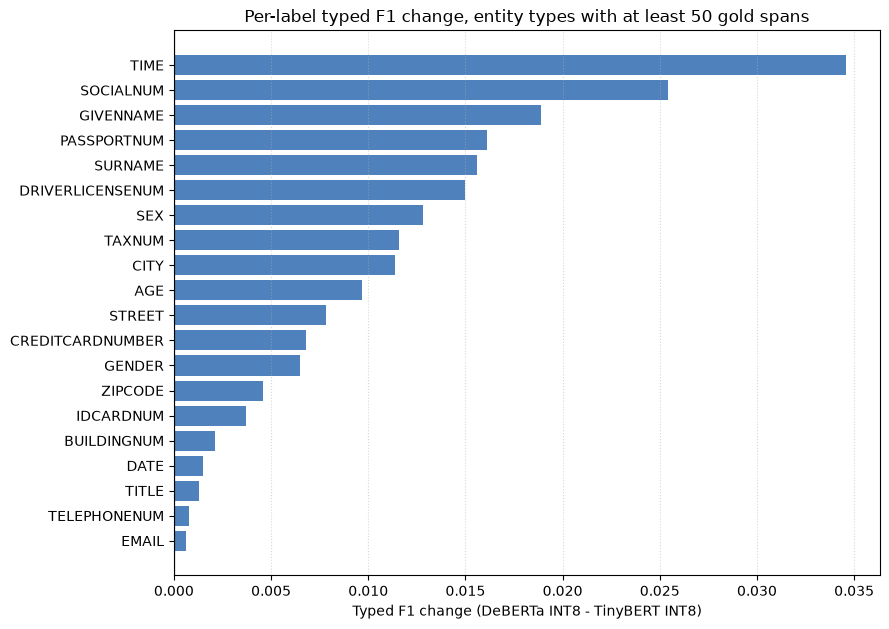

In [20]:
plot_frame = WELL_SUPPORTED.sort_values("Change")
figure, axes = plt.subplots(figsize=(9, max(4, 0.32 * len(plot_frame))))
colors = ["#c0504d" if value < 0 else "#4f81bd" for value in plot_frame["Change"]]
axes.barh(plot_frame.index, plot_frame["Change"], color=colors)
axes.axvline(0, color="black", linewidth=0.8)
axes.set_xlabel("Typed F1 change (DeBERTa INT8 - TinyBERT INT8)")
axes.set_title("Per-label typed F1 change, entity types with at least 50 gold spans")
axes.grid(axis="x", linestyle=":", alpha=0.5)
figure.tight_layout()
plt.show()

## 13. Model size and runtime

Two different measurements:

* **Throughput** - wall-clock time for the full evaluation above, both models
  using the same `WORKERS x THREADS_PER_WORKER` budget.
* **Single-stream latency** - one example at a time on one CPU thread, over the
  first `LATENCY_ROWS` validation rows after a warm-up, which is the closer
  analogue of masking one utterance in the live pipeline.

Both are measured on the desktop machine printed in section 2. **They are not
deployment-device numbers.** Latency, memory and thermal behaviour on the target
edge device have to be measured on that device; nothing here substitutes for
that.

In [21]:
def measure_latency(model_path: Path, tokenizer_dir: Path, id2label: dict[int, str],
                    *, tokenizer_word_ids: bool) -> dict:
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    session = ort.InferenceSession(str(model_path), options, providers=["CPUExecutionProvider"])
    tokenizer = AutoTokenizer.from_pretrained(
        str(tokenizer_dir), local_files_only=True, use_fast=True
    )

    sample = TEXTS[:LATENCY_ROWS]
    for text in sample[:LATENCY_WARMUP]:
        predict_spans(session, tokenizer, id2label, text, tokenizer_word_ids=tokenizer_word_ids)

    timings = []
    for text in sample:
        started = time.perf_counter()
        predict_spans(session, tokenizer, id2label, text, tokenizer_word_ids=tokenizer_word_ids)
        timings.append((time.perf_counter() - started) * 1000.0)
    del session
    values = np.array(timings)
    return {
        "rows": len(values),
        "mean_ms": float(values.mean()),
        "median_ms": float(np.median(values)),
        "p95_ms": float(np.percentile(values, 95)),
    }


tinybert_latency = measure_latency(TINYBERT_MODEL_PATH, TINYBERT_TOKENIZER_DIR,
                                   TINYBERT_ID2LABEL, tokenizer_word_ids=True)
deberta_latency = measure_latency(DEBERTA_MODEL_PATH, DEBERTA_TOKENIZER_DIR,
                                  DEBERTA_ID2LABEL, tokenizer_word_ids=False)

RUNTIME = pd.DataFrame(
    [
        {"Measurement": "Artifact size (MiB)",
         "TinyBERT INT8": round(TINYBERT_ARTIFACT["mib"], 2),
         "DeBERTa INT8": round(DEBERTA_ARTIFACT["mib"], 2)},
        {"Measurement": "Weight tensor elements",
         "TinyBERT INT8": TINYBERT_GRAPH["weight_elements"],
         "DeBERTa INT8": DEBERTA_GRAPH["weight_elements"]},
        {"Measurement": f"Full evaluation, {WORKERS}x{THREADS_PER_WORKER} threads (s)",
         "TinyBERT INT8": round(tinybert_seconds, 1),
         "DeBERTa INT8": round(deberta_seconds, 1)},
        {"Measurement": "Throughput (examples/s)",
         "TinyBERT INT8": round(len(TEXTS) / tinybert_seconds, 1),
         "DeBERTa INT8": round(len(TEXTS) / deberta_seconds, 1)},
        {"Measurement": "Single-thread latency, median (ms)",
         "TinyBERT INT8": round(tinybert_latency["median_ms"], 2),
         "DeBERTa INT8": round(deberta_latency["median_ms"], 2)},
        {"Measurement": "Single-thread latency, mean (ms)",
         "TinyBERT INT8": round(tinybert_latency["mean_ms"], 2),
         "DeBERTa INT8": round(deberta_latency["mean_ms"], 2)},
        {"Measurement": "Single-thread latency, p95 (ms)",
         "TinyBERT INT8": round(tinybert_latency["p95_ms"], 2),
         "DeBERTa INT8": round(deberta_latency["p95_ms"], 2)},
    ]
).set_index("Measurement")

RUNTIME["Ratio (DeBERTa / TinyBERT)"] = (
    RUNTIME["DeBERTa INT8"] / RUNTIME["TinyBERT INT8"]
).round(2)
RUNTIME

,TinyBERT INT8,DeBERTa INT8,Ratio (DeBERTa / TinyBERT)
Measurement,,,
Artifact size (MiB),13.72,78.47,5.72
Weight tensor elements,14274665.00,70706502.00,4.95
"Full evaluation, 10x2 threads (s)",596.80,1801.80,3.02
Throughput (examples/s),68.50,22.70,0.33
"Single-thread latency, median (ms)",14.97,76.33,5.10
"Single-thread latency, mean (ms)",22.07,104.47,4.73
"Single-thread latency, p95 (ms)",60.36,265.82,4.40


## 14. Interpretation

In [22]:
tiny_f1 = tinybert_metrics["typed_entity"]["f1"]
deb_f1 = deberta_metrics["typed_entity"]["f1"]
tiny_leak = tinybert_metrics["leakage"]
deb_leak = deberta_metrics["leakage"]

leak_note = (
    f"{tiny_leak / deb_leak:.1f}x less PII left in the text"
    if deb_leak and deb_leak < tiny_leak
    else "lower is better"
)

print("Benefit")
print(f"  typed F1        {tiny_f1:.4f} -> {deb_f1:.4f}   "
      f"({deb_f1 - tiny_f1:+.4f}, {100 * (deb_f1 - tiny_f1) / tiny_f1:+.1f}% relative)")
print(f"  typed F1 error  {100 * (1 - (1 - deb_f1) / (1 - tiny_f1)):.1f}% of the remaining error removed")
print(f"  leakage         {tiny_leak:.4f} -> {deb_leak:.4f}   ({leak_note})")
print()
print("Cost")
print(f"  artifact        {TINYBERT_ARTIFACT['mib']:.1f} MiB -> {DEBERTA_ARTIFACT['mib']:.1f} MiB "
      f"({DEBERTA_ARTIFACT['mib'] / TINYBERT_ARTIFACT['mib']:.1f}x)")
print(f"  latency         {tinybert_latency['median_ms']:.1f} ms -> {deberta_latency['median_ms']:.1f} ms "
      f"({deberta_latency['median_ms'] / tinybert_latency['median_ms']:.1f}x, single desktop thread)")

Benefit
  typed F1        0.9502 -> 0.9588   (+0.0086, +0.9% relative)
  typed F1 error  17.2% of the remaining error removed
  leakage         0.0029 -> 0.0017   (1.7x less PII left in the text)

Cost
  artifact        13.7 MiB -> 78.5 MiB (5.7x)
  latency         15.0 ms -> 76.3 ms (5.1x, single desktop thread)


### What the numbers say

**DeBERTa is better on every metric measured here, and by a small margin on the
headline one.** Typed F1 moves from 0.9502 to 0.9588: +0.0086 absolute, +0.9%
relative, which removes about 17% of the exact-boundary error TinyBERT still
made. That is a real improvement but not a different league; TinyBERT was
already strong on this distribution.

**The clearest practical gain is at row level.** The share of examples where the
predicted span set matches gold *exactly* rises from 0.7413 to 0.7844. Put the
other way, the share of rows with at least one span wrong falls from 25.9% to
21.6% - about one in six of the imperfect rows is now clean. Aggregate F1
understates that, because a row with one bad boundary among six correct spans
still contributes five true positives.

**Both privacy-facing directions improved at once.** Leakage - PII characters
left in the released text - falls from 0.0029 to 0.0017, about 1.7x less. At the
same time overmasking falls from 0.0044 to 0.0029, so fewer innocent characters
are redacted. These usually trade against each other; here the newer model is
better at both, which means the gain is genuine boundary accuracy rather than a
shifted operating point. Character recall is above 0.997 for both models, so
almost nothing escapes either one *unmasked* - what improved is precisely where
the mask starts and stops.

**Which labels benefited.** The largest gains among well-supported types are
`TIME` (+0.035), `SOCIALNUM` (+0.025), `GIVENNAME` (+0.019), `PASSPORTNUM`
(+0.016), `SURNAME` (+0.016) and `DRIVERLICENSENUM` (+0.015). `GIVENNAME` and
`SURNAME` matter most in absolute terms: together they carry about 70,000 of the
311,469 gold spans, so a 1.5-2 point gain on them moves the aggregate more than
a larger gain on a rare type would.

**No label regressed.** Among the 20 entity types with at least 50 gold spans,
none lost F1. The seven types below that threshold (`URL`, `ORGANISATION`,
`CURRENCY`, `ACCOUNTNUM`, `COUNTRY`, `BANKNAME`, `AMOUNT`) have between one and
five gold spans in this split and are simply not measurable here - the apparent
`URL` and `ORGANISATION` movements rest on five and four spans respectively and
should not be read as evidence either way.

**Where the remaining error still is.** DeBERTa's weakest well-supported labels
are `SURNAME` (0.891), `DRIVERLICENSENUM` (0.900), `GIVENNAME` (0.900) and
`IDCARDNUM` (0.901). Those were also TinyBERT's weakest, so the new model
narrowed the same gaps rather than opening new ones: person names and free-form
identifier numbers are where boundary decisions are genuinely ambiguous.

**The label spaces turned out not to matter.** Neither model emitted a single
prediction outside the 30 entity types they share - no `USERNAME`, `WEIGHT` or
`ALLERGIES` from TinyBERT, no `PASSWORD` from DeBERTa - so section 11 reproduces
section 10 exactly. The comparison does not depend on the ontology change.

**The cost is size and speed.** The artifact grows 5.7x, from 13.7 MiB to
78.5 MiB, and single-thread median latency grows about 5x, from 15 ms to 76 ms
on this desktop CPU. That is the real trade: roughly a fifth of the remaining
exact-boundary error, and 1.7x less leaked PII, in exchange for five times the
model and five times the compute per utterance. Whether that trade is
acceptable is a question about the deployment device's latency budget, memory
headroom and thermal envelope - and it has to be answered by measuring on that
device, not from the desktop numbers in section 13.

## 15. Limitations

**These results measure performance on this held-out validation distribution and
do not guarantee equivalent performance on arbitrary real-world text.**

Specifically:

* **One distribution.** AI4Privacy's English validation split is largely
  synthetic, template-generated business and administrative prose. Real speech
  transcripts are messier - no punctuation, disfluencies, transcription errors -
  and neither model should be expected to hold these numbers there.
  Out-of-distribution behaviour is measured separately and is not part of this
  notebook.
* **Label-space asymmetry.** The gold ontology has 31 entity types, matching the
  newer model. Section 11 repeats the comparison on the 30 shared types to show
  the conclusion does not rest on that asymmetry.
* **Model only.** The deployed pipeline also runs deterministic recognizers for
  structured identifiers and a fail-closed policy layer. Both are disabled here,
  because the question is what the neural models themselves learned. Deployed
  end-to-end numbers differ.
* **Exact boundaries.** Typed F1 requires character-exact boundaries. A span one
  character too long scores zero even though it leaks nothing, which is why
  character recall and leakage are reported next to it.
* **Desktop timings.** Section 13 is local throughput on a desktop CPU. It says
  nothing about latency, memory headroom or sustained thermal behaviour on the
  deployment device.
* **Quantized artifacts only.** Both models are measured as INT8 ONNX, which is
  what ships. Their FP32 parents are not evaluated here.